In [1]:
import pandas as pd
import os

file_path = os.path.join('data', '1553768847-housing.csv')

try:
    df = pd.read_csv(file_path)
    print(f"Số lượng dòng: {df.shape[0]}, Số lượng cột: {df.shape[1]}")
    display(df.info())
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file tại {file_path}.")

Số lượng dòng: 20640, Số lượng cột: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


None

In [2]:
# One-Hot Encoding cho biến định tính 'ocean_proximity'
if 'ocean_proximity' in df.columns:
    df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
    
# Điền giá trị thiếu cho total_bedrooms bằng Median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Tạo các biến tỉ lệ để tăng hiệu quả mô hình
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']



print("Tiền xử lý hoàn tất!")
display(df.describe())

Tiền xử lý hoàn tất!


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909,5.429000,0.213794,3.070655
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874,2.474173,0.065248,10.386050
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.037151,0.692308
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000,4.440716,0.175225,2.429741
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,5.229129,0.203159,2.818116
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000,6.052381,0.240126,3.282261
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,2.824675,1243.333333


In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    X_numeric = X.astype(float)
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_numeric.columns
    vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(len(X_numeric.columns))]
    return vif_data

# Loại bỏ biến mục tiêu trước khi tính VIF
X_vif = df.drop('median_house_value', axis=1)
print(calculate_vif(X_vif))

                       feature         VIF
0                    longitude  928.599726
1                     latitude  827.926622
2           housing_median_age    8.136709
3                  total_rooms   40.733621
4               total_bedrooms   94.239353
5                   population   17.491861
6                   households   93.927713
7                median_income   10.086550
8       ocean_proximity_INLAND    2.754470
9       ocean_proximity_ISLAND    1.001734
10    ocean_proximity_NEAR BAY    1.677194
11  ocean_proximity_NEAR OCEAN    1.310203
12         rooms_per_household    9.302206
13           bedrooms_per_room   25.708691
14    population_per_household    1.156108


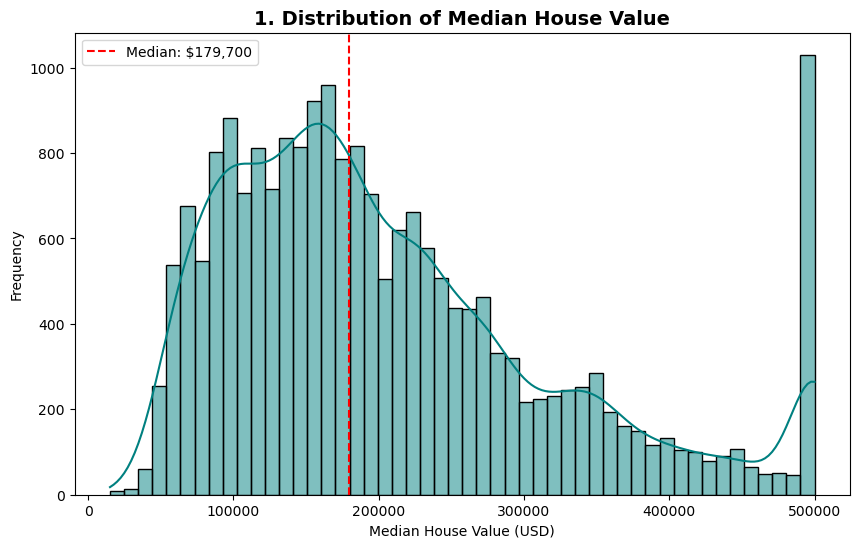

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], kde=True, color='teal', bins=50)

plt.axvline(df['median_house_value'].median(), color='red', linestyle='--', 
            label=f"Median: ${df['median_house_value'].median():,.0f}")

plt.title('1. Distribution of Median House Value', fontsize=14, fontweight='bold')
plt.xlabel('Median House Value (USD)')
plt.ylabel('Frequency') 

plt.legend()
plt.show()

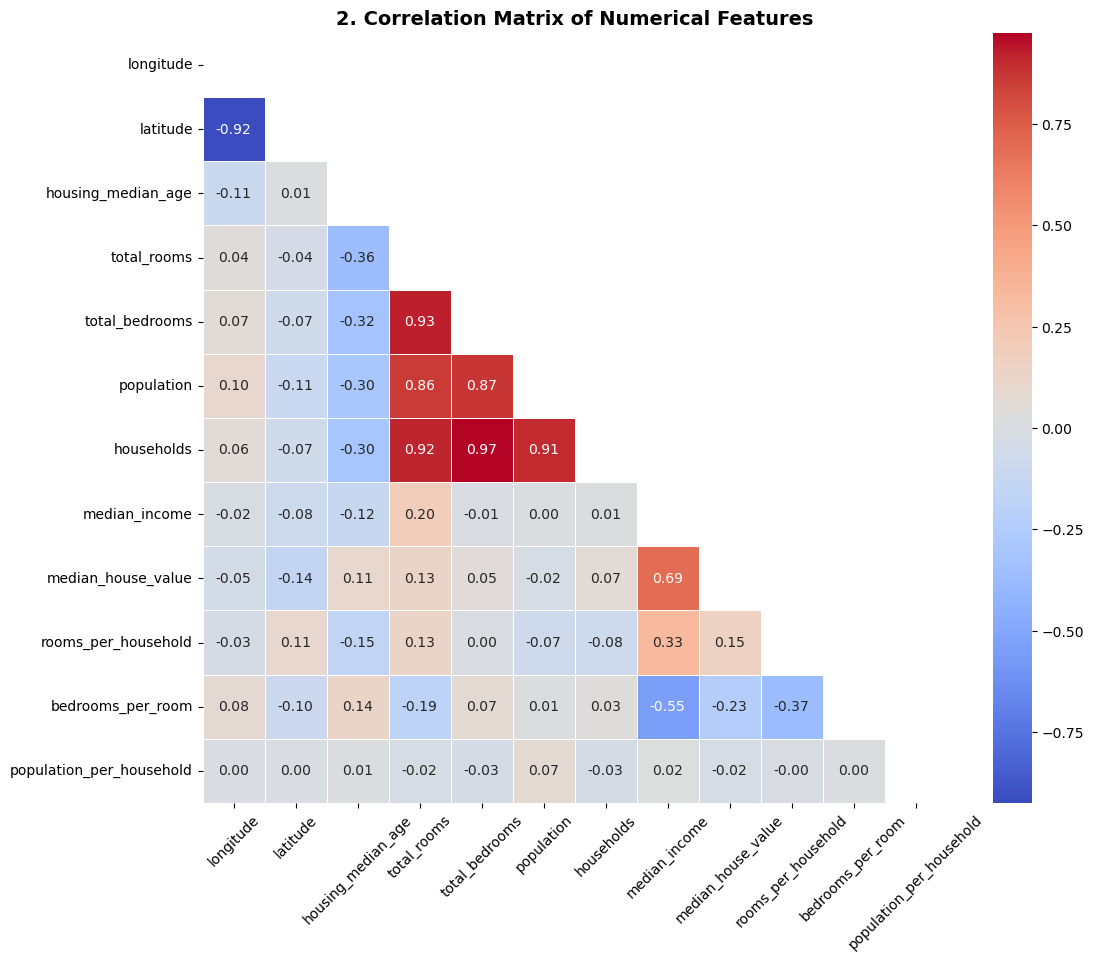

In [5]:
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) 

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, annot_kws={"size": 10})
plt.title('2. Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='median_income', y='median_house_value', 
            scatter_kws={'alpha':0.2, 'color':'teal'}, 
            line_kws={'color':'red', 'label':'Regression Line'})

plt.title("Linear Relationship between Median Income and House Value", fontsize=14, fontweight='bold')
plt.xlabel("Median Income (in $10,000s)")
plt.ylabel("Median House Value (USD)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

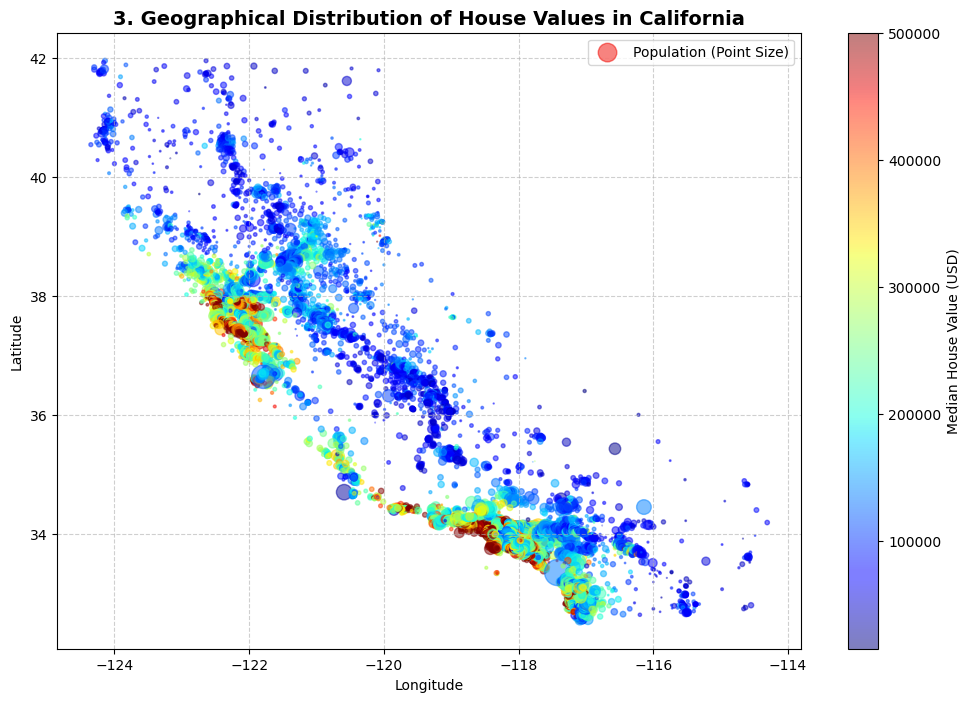

In [ ]:
plt.figure(figsize=(12, 8))
sc = plt.scatter(df['longitude'], df['latitude'], alpha=0.5,
                 s=df['population']/100, label='Population (Point Size)',
                 c=df['median_house_value'], cmap=plt.get_cmap('jet'))

plt.colorbar(sc, label='Median House Value (USD)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('3. Geographical Distribution of House Values in California', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Nhóm các biến có đơn vị lớn
cols_scale = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_house_value']

plt.figure(figsize=(18, 10))
for i, col in enumerate(cols_scale):
    plt.subplot(2, 3, i + 1) 
    sns.boxplot(y=df[col], color='skyblue', fliersize=3)
    plt.title(f'Outliers: {col}', fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

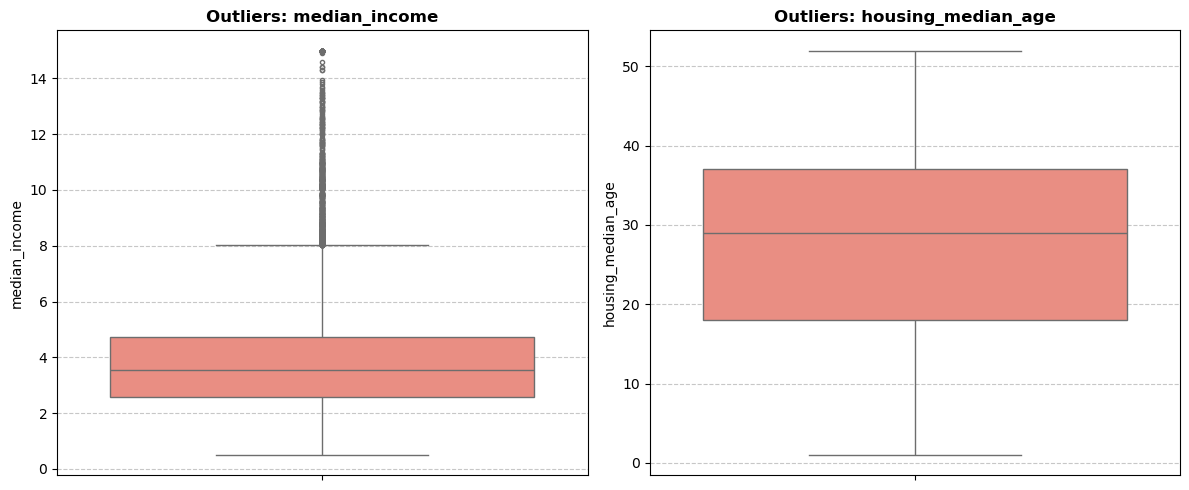

In [ ]:
# Nhóm các biến có đơn vị nhỏ
cols_feature = ['median_income', 'housing_median_age']

plt.figure(figsize=(12, 5))
for i, col in enumerate(cols_feature):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(y=df[col], color='salmon', fliersize=3)
    plt.title(f'Outliers: {col}', fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.cluster import KMeans
import statsmodels.api as sm

# ==========================================
# BƯỚC 1: CHIA TẬP DỮ LIỆU (TRAIN/TEST)
# ==========================================
# Biến mục tiêu
y = df['median_house_value']
# Biến độc lập (loại bỏ biến mục tiêu)
X = df.drop('median_house_value', axis=1)

# 80% Train - 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Đã chia dữ liệu: Train ({len(X_train)} mẫu), Test ({len(X_test)} mẫu)")

# ==========================================
# BƯỚC 2: HUẤN LUYỆN 7 MÔ HÌNH 
# ==========================================

# Danh sách biến đã lọc đa cộng tuyến (VIF) cho Model 2 & 7
vif_cols = ['housing_median_age', 'median_income', 'rooms_per_household', 
            'bedrooms_per_room', 'population_per_household'] + [col for col in X_train.columns if 'ocean_proximity' in col]

#  Model 1: Baseline  
model1 = LinearRegression().fit(X_train, y_train)

#  Model 2: VIF Optimized 
model2 = LinearRegression().fit(X_train[vif_cols], y_train)

#  Model 3: Log-Log Transform 
X_train_log = X_train.copy()
X_train_log['median_income'] = np.log1p(X_train_log['median_income'])
model3 = LinearRegression().fit(X_train_log, np.log1p(y_train))

# Model 4: Interaction
X_train_int = X_train.copy()
if 'ocean_proximity_INLAND' in X_train.columns:
    X_train_int['income_inland'] = X_train['median_income'] * X_train['ocean_proximity_INLAND']
model4 = LinearRegression().fit(X_train_int, y_train)

#  Model 5: Polynomial (Bậc 2 cho Median Income) 
poly = PolynomialFeatures(degree=2, include_bias=False)
income_poly_train = poly.fit_transform(X_train[['median_income']])
X_train_poly = np.hstack([X_train.drop('median_income', axis=1).values, income_poly_train])
model5 = LinearRegression().fit(X_train_poly, y_train)

# Model 6: Spatial Clustering (Gom nhóm tọa độ) 
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_train = kmeans.fit_predict(X_train[['longitude', 'latitude']])
X_train_spatial = pd.concat([X_train.reset_index(drop=True), pd.get_dummies(clusters_train, prefix='cluster')], axis=1)
model6 = LinearRegression().fit(X_train_spatial, y_train.values)

#  Model 7: Outlier Cleaned (Dùng khoảng cách Cook) 
X_const = sm.add_constant(X_train[vif_cols].astype(float))
ols_res = sm.OLS(y_train.values, X_const).fit()
cooks_d = ols_res.get_influence().cooks_distance[0]
clean_idx = cooks_d < (4 / len(X_train))
model7 = LinearRegression().fit(X_train[vif_cols][clean_idx], y_train[clean_idx])

print("Đã huấn luyện xong 7 mô hình.")

# ==========================================
# BƯỚC 3: CHUẨN BỊ TẬP TEST TƯƠNG ỨNG
# ==========================================
# Model 3 Test
X_test_log = X_test.copy()
X_test_log['median_income'] = np.log1p(X_test_log['median_income'])

# Model 4 Test
X_test_int = X_test.copy()
if 'ocean_proximity_INLAND' in X_test.columns:
    X_test_int['income_inland'] = X_test['median_income'] * X_test['ocean_proximity_INLAND']

# Model 5 Test
income_poly_test = poly.transform(X_test[['median_income']])
X_test_poly = np.hstack([X_test.drop('median_income', axis=1).values, income_poly_test])

# Model 6 Test
clusters_test = kmeans.predict(X_test[['longitude', 'latitude']])
X_test_spatial = pd.concat([X_test.reset_index(drop=True), pd.get_dummies(clusters_test, prefix='cluster')], axis=1)

# ==========================================
# BƯỚC 4: MODEL EVALUATION
# ==========================================
def get_metrics(model, X_v, y_v, name, is_log=False):
    preds = model.predict(X_v)
    if is_log: preds = np.expm1(preds) 
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_v, preds),
        'RMSE': np.sqrt(mean_squared_error(y_v, preds)),
        'R2': r2_score(y_v, preds)
    }

performance_results = [
    get_metrics(model1, X_test, y_test, "M1: Baseline"),
    get_metrics(model2, X_test[vif_cols], y_test, "M2: VIF Optimized"),
    get_metrics(model3, X_test_log, y_test, "M3: Log-Log", is_log=True),
    get_metrics(model4, X_test_int, y_test, "M4: Interaction"),
    get_metrics(model5, X_test_poly, y_test, "M5: Polynomial"),
    get_metrics(model6, X_test_spatial, y_test, "M6: Spatial Cluster"),
    get_metrics(model7, X_test[vif_cols], y_test, "M7: Outlier Cleaned")
]

summary_df = pd.DataFrame(performance_results)
display(summary_df.sort_values(by='R2', ascending=False))

Đã chia dữ liệu: Train (16512 mẫu), Test (4128 mẫu)
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4']
Đã huấn luyện xong 7 mô hình.


,Model,MAE,RMSE,R2
5,M6: Spatial Cluster,49924.740915,71084.901375,0.614390
3,M4: Interaction,50787.820567,72565.185111,0.598163
0,M1: Baseline,50888.660016,72668.538379,0.597018
4,M5: Polynomial,51565.223673,74201.567259,0.579836
1,M2: VIF Optimized,53818.611431,77307.848582,0.543921
6,M7: Outlier Cleaned,52449.497165,81337.263724,0.495138
2,M3: Log-Log,60254.907500,685760.869434,-34.887114


In [ ]:
# Lấy hệ số của Model 6
features_m6 = X_train_spatial.columns
coefficients = model6.coef_

coeff_df = pd.DataFrame({'Feature': features_m6, 'Coefficients': coefficients})
print(coeff_df.sort_values(by='Coefficients', ascending=False))

                       Feature   Coefficients
13           bedrooms_per_room  258928.327917
9       ocean_proximity_ISLAND  126727.585860
7                median_income   39627.034513
18                   cluster_3   17501.229363
11  ocean_proximity_NEAR OCEAN   15323.286237
16                   cluster_1   11163.557451
12         rooms_per_household    3268.985232
2           housing_median_age     935.725855
6                   households     100.493005
14    population_per_household      85.836253
4               total_bedrooms      14.135570
3                  total_rooms       3.527592
5                   population     -41.934918
10    ocean_proximity_NEAR BAY   -1174.205838
19                   cluster_4   -2209.687794
15                   cluster_0  -10258.310344
17                   cluster_2  -16196.788675
1                     latitude  -26360.020375
0                    longitude  -27662.453140
8       ocean_proximity_INLAND  -29095.653923


In [ ]:
import joblib

# Lưu mô hình số 6 (Spatial Cluster)
joblib.dump(model6, 'model_6.pkl')

# Lưu kmeans để xử lý tọa độ trên web nếu cần
joblib.dump(kmeans, 'spatial_cluster_model.pkl')

['spatial_cluster_model.pkl']